# Spain: Digital Echoes vs. Bed Nights
## DTU 42578 Advanced Business Analytics — Spain Component

**Research Question:** Do digital attention signals (Google Trends) predict Spain's tourism demand with a measurable lead time?

**Pipeline:**
1. Collect Google Trends signals for 6 major Spanish cities (2020–2026)
2. Load Eurostat monthly accommodation nights for Spain
3. Detect demand shocks (>2σ above 3-year rolling baseline)
4. Compute attention lead time (GT spike precedes arrival spike?)
5. Random Forest + SHAP: which city/signal type is the strongest predictor?
6. Visualizations: Early Warning Chart + City Radar Profile

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# pytrends fix: urllib3 v2 removed method_whitelist; patch before importing TrendReq
import urllib3.util.retry as _retry_module
if not hasattr(_retry_module.Retry.__init__, '_patched'):
    _orig_init = _retry_module.Retry.__init__
    def _patched_init(self, *args, **kwargs):
        kwargs.pop('method_whitelist', None)
        _orig_init(self, *args, **kwargs)
    _patched_init._patched = True
    _retry_module.Retry.__init__ = _patched_init

from pytrends.request import TrendReq
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error, r2_score
import shap
import time, random
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE         = Path('/Users/alex/viral_tourism')
RAW          = BASE / 'data' / 'raw'
PROC         = BASE / 'data' / 'processed'
EUROSTAT_TSV = BASE / 'group_repo' / 'estat_tour_occ_nim.tsv'
WIKI_CSV     = Path('/Users/alex/Library/Containers/net.whatsapp.WhatsApp/Data/tmp/documents/E7A6027B-5D86-42EA-9718-D4F20EB1AE5A/eu_tourism_resilience_merged.csv')

RAW.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)

print('Environment ready. numpy', np.__version__, '| pandas', pd.__version__, '| shap', shap.__version__)

Environment ready. numpy 1.26.4 | pandas 3.0.2 | shap 0.45.1


## Section 1: Google Trends Configuration

Six major Spanish tourism cities. For each city, 6 signal types matching the group schema:
`gt_airbnb`, `gt_hotel`, `gt_flights`, `gt_attraction_1`, `gt_attraction_2`, `gt_attraction_3`

In [2]:
REGIONS = {
    'barcelona': {
        'gt_airbnb':       'Barcelona airbnb',
        'gt_hotel':        'Barcelona hotel',
        'gt_flights':      'Barcelona flights',
        'gt_attraction_1': 'Sagrada Familia',
        'gt_attraction_2': 'Park Guell',
        'gt_attraction_3': 'Barcelona festival',
    },
    'madrid': {
        'gt_airbnb':       'Madrid airbnb',
        'gt_hotel':        'Madrid hotel',
        'gt_flights':      'Madrid flights',
        'gt_attraction_1': 'Prado Museum',
        'gt_attraction_2': 'Retiro Park',
        'gt_attraction_3': 'Madrid festival',
    },
    'valencia': {
        'gt_airbnb':       'Valencia airbnb',
        'gt_hotel':        'Valencia hotel',
        'gt_flights':      'Valencia flights',
        'gt_attraction_1': 'City of Arts and Sciences',
        'gt_attraction_2': 'Valencia Cathedral',
        'gt_attraction_3': 'Las Fallas',
    },
    'balearics': {
        'gt_airbnb':       'Mallorca airbnb',
        'gt_hotel':        'Mallorca hotel',
        'gt_flights':      'Mallorca flights',
        'gt_attraction_1': 'Palma de Mallorca',
        'gt_attraction_2': 'Formentera',
        'gt_attraction_3': 'Ibiza festival',
    },
    'andalusia': {
        'gt_airbnb':       'Seville airbnb',
        'gt_hotel':        'Seville hotel',
        'gt_flights':      'Malaga flights',
        'gt_attraction_1': 'Alhambra',
        'gt_attraction_2': 'Seville Cathedral',
        'gt_attraction_3': 'Feria de Abril',
    },
    'canary': {
        'gt_airbnb':       'Tenerife airbnb',
        'gt_hotel':        'Tenerife hotel',
        'gt_flights':      'Tenerife flights',
        'gt_attraction_1': 'Teide volcano',
        'gt_attraction_2': 'Gran Canaria',
        'gt_attraction_3': 'Canary Islands festival',
    },
}

GT_COLS     = ['gt_airbnb','gt_hotel','gt_flights','gt_attraction_1','gt_attraction_2','gt_attraction_3']
TIMEFRAME   = '2020-01-01 2026-03-31'
CITIES      = list(REGIONS.keys())
print(f'Cities: {CITIES}')
print(f'Signals per city: {GT_COLS}')

Cities: ['barcelona', 'madrid', 'valencia', 'balearics', 'andalusia', 'canary']
Signals per city: ['gt_airbnb', 'gt_hotel', 'gt_flights', 'gt_attraction_1', 'gt_attraction_2', 'gt_attraction_3']


## Section 2: Google Trends Collection

Fetches monthly GT data per city. Results cached to `data/raw/gt_{city}.csv` — safe to re-run.
First run: ~30–45 minutes due to rate-limiting. Subsequent runs: instant.

**Note:** pytrends allows max 5 keywords per call. 6 signals → 2 batches per city (5+1).

In [3]:
def fetch_gt_city(city_key, region_cfg, timeframe=TIMEFRAME, max_retries=5):
    """Fetch GT for one city. Returns DataFrame with date + 6 GT columns.
    Caches to data/raw/gt_{city_key}.csv; skips network call if file exists."""
    cache_path = RAW / f'gt_{city_key}.csv'
    if cache_path.exists():
        print(f'  [{city_key}] loading from cache')
        return pd.read_csv(cache_path, parse_dates=['date'])

    pytrends = TrendReq(hl='en-US', tz=60, timeout=(10, 30))
    queries  = [region_cfg[col] for col in GT_COLS]
    results  = {}
    last_df  = None

    for b_start in range(0, len(queries), 5):
        batch_q    = queries[b_start:b_start+5]
        batch_cols = GT_COLS[b_start:b_start+5]

        for attempt in range(max_retries):
            try:
                pytrends.build_payload(batch_q, cat=0, timeframe=timeframe, geo='ES', gprop='')
                df = pytrends.interest_over_time()
                if df.empty:
                    raise ValueError('empty response')
                last_df = df
                for col, q in zip(batch_cols, batch_q):
                    results[col] = df[q] if q in df.columns else np.nan
                sleep_s = random.uniform(8, 15)
                print(f'  [{city_key}] batch {b_start//5+1} ok — sleeping {sleep_s:.1f}s')
                time.sleep(sleep_s)
                break
            except Exception as e:
                wait = (2 ** attempt) * random.uniform(15, 30)
                print(f'  [{city_key}] attempt {attempt+1} failed: {e} — waiting {wait:.0f}s')
                if attempt < max_retries - 1:
                    time.sleep(wait)
                else:
                    print(f'  [{city_key}] giving up on batch — filling NaN')
                    for col in batch_cols:
                        results[col] = np.nan

    if last_df is not None:
        idx = last_df.index
    else:
        idx = pd.date_range('2020-01-01', '2026-03-01', freq='MS')

    out = pd.DataFrame(results, index=idx)
    out.index.name = 'date'
    out = out.reset_index()
    out.insert(1, 'country', 'Spain')
    out.insert(2, 'city', city_key)
    out.to_csv(cache_path, index=False)
    print(f'  [{city_key}] saved to {cache_path}')
    return out


print('Starting GT collection (cached — instant if already fetched)...')
gt_frames = []
for city_key, region_cfg in REGIONS.items():
    print(f'Processing: {city_key}')
    df = fetch_gt_city(city_key, region_cfg)
    gt_frames.append(df)
    time.sleep(random.uniform(5, 10))

gt_long = pd.concat(gt_frames, ignore_index=True)
gt_long['date'] = pd.to_datetime(gt_long['date'])
print(f'\nGT collection complete. Shape: {gt_long.shape}')
gt_long.head(3)

Starting GT collection (cached — instant if already fetched)...
Processing: barcelona
  [barcelona] loading from cache
Processing: madrid
  [madrid] loading from cache
Processing: valencia
  [valencia] loading from cache
Processing: balearics
  [balearics] loading from cache
Processing: andalusia
  [andalusia] loading from cache
Processing: canary
  [canary] loading from cache

GT collection complete. Shape: (450, 9)


,date,country,city,gt_airbnb,gt_hotel,gt_flights,gt_attraction_1,gt_attraction_2,gt_attraction_3
0,2020-01-01,Spain,barcelona,4,54,12,48,6,29
1,2020-02-01,Spain,barcelona,4,58,6,50,7,50
2,2020-03-01,Spain,barcelona,2,27,5,36,3,22


In [4]:
# ── GT quality check ──────────────────────────────────────────────────────────
print('=== GT Data Quality ===')
print(f'Rows: {len(gt_long)}  (expect {len(CITIES)} cities × ~75 months = {len(CITIES)*75})')
print(f'Date range: {gt_long["date"].min().date()} to {gt_long["date"].max().date()}')
print(f'Cities: {sorted(gt_long["city"].unique())}')
print(f'\nNaN % per signal column:')
nan_pct = gt_long[GT_COLS].isna().mean() * 100
print(nan_pct.round(1).to_string())
for col in GT_COLS:
    if nan_pct[col] > 20:
        print(f'WARNING: {col} has {nan_pct[col]:.0f}% NaN — consider re-fetching')

=== GT Data Quality ===
Rows: 450  (expect 6 cities × ~75 months = 450)
Date range: 2020-01-01 to 2026-03-01
Cities: ['andalusia', 'balearics', 'barcelona', 'canary', 'madrid', 'valencia']

NaN % per signal column:
gt_airbnb          0.0
gt_hotel           0.0
gt_flights         0.0
gt_attraction_1    0.0
gt_attraction_2    0.0
gt_attraction_3    0.0


## Section 3: Eurostat Accommodation Nights

Source: `estat_tour_occ_nim.tsv` (group repo)  
Filter: Spain (`geo=ES`), all accommodation types (`nace_r2=I551-I553`), total residents (`c_resid=TOTAL`), nights (`unit=NR`)  
Output: monthly `nights_spent` for Spain, 2020–2026

In [5]:
def load_eurostat_spain(tsv_path):
    cache = PROC / 'eurostat_spain_nights.csv'
    if cache.exists():
        print('Loading Eurostat from cache')
        return pd.read_csv(cache, parse_dates=['date'])

    print(f'Parsing {tsv_path} ...')
    raw = pd.read_csv(tsv_path, sep='\t', low_memory=False)
    key_col = raw.columns[0]
    raw[['freq','c_resid','unit','nace_r2','geo']] = raw[key_col].str.split(',', expand=True)
    for c in ['c_resid','unit','nace_r2','geo']:
        raw[c] = raw[c].str.strip()

    mask = (
        (raw['geo']     == 'ES') &
        (raw['c_resid'] == 'TOTAL') &
        (raw['unit']    == 'NR') &
        (raw['nace_r2'] == 'I551-I553')
    )
    sub = raw[mask].copy()
    print(f'Matched rows: {len(sub)}')
    if len(sub) == 0:
        print('WARNING: 0 rows matched. Available values:')
        print('  c_resid:', raw['c_resid'].unique())
        print('  unit:   ', raw['unit'].unique())
        print('  nace_r2:', raw['nace_r2'].unique())
        return pd.DataFrame(columns=['date','nights_spent'])

    id_vars   = ['freq','c_resid','unit','nace_r2','geo']
    date_cols = [c for c in sub.columns if c not in id_vars and c != key_col]
    long = sub.melt(id_vars=id_vars, value_vars=date_cols,
                    var_name='period', value_name='nights_spent')

    long['period'] = long['period'].str.strip()
    long['date']   = pd.to_datetime(long['period'], format='%Y-%m', errors='coerce')
    long = long.dropna(subset=['date'])

    long['nights_spent'] = (
        long['nights_spent'].astype(str)
        .str.replace(r'[^0-9.]', '', regex=True)
        .replace('', np.nan)
        .astype(float)
    )

    out = long[long['date'] >= '2020-01-01'][['date','nights_spent']].sort_values('date').reset_index(drop=True)
    out.to_csv(cache, index=False)
    print(f'Saved. Shape: {out.shape}')
    return out


eurostat = load_eurostat_spain(EUROSTAT_TSV)
print(f'\nDate range: {eurostat["date"].min().date()} to {eurostat["date"].max().date()}')
print(f'NaN nights_spent: {eurostat["nights_spent"].isna().sum()}')
eurostat.tail(6)

Loading Eurostat from cache

Date range: 2020-01-01 to 2026-02-01
NaN nights_spent: 1


,date,nights_spent
68,2025-09-01,53888369.0
69,2025-10-01,44751911.0
70,2025-11-01,27377889.0
71,2025-12-01,25809552.0
72,2026-01-01,24000682.0
73,2026-02-01,NaN


## Section 4: Build Master Shock Table

**Design:** GT data is city-level (long format); Eurostat is national (one row per month).
We merge by date, then pivot GT wide (one column per city×signal) for modeling.

**Shock detection:**
- `is_arrival_shock`: `nights_spent > rolling_mean + 2σ` (36-month window, 1-month shift)
- `is_attention_spike`: combined GT signal for that city > expanding mean + 2σ
- `attn_led_arrival`: attention spike in t−1 or t−2 AND arrival shock in t

In [6]:
# ── Merge: GT (long) × Eurostat (national) ────────────────────────────────────
merged = pd.merge(gt_long, eurostat, on='date', how='inner')
merged = merged.sort_values(['city','date']).reset_index(drop=True)
print(f'Merged shape: {merged.shape}')
print(f'Cities: {merged["city"].unique()}')
print(f'Date range: {merged["date"].min().date()} to {merged["date"].max().date()}')

Merged shape: (444, 10)
Cities: <ArrowStringArray>
['andalusia', 'balearics', 'barcelona', 'canary', 'madrid', 'valencia']
Length: 6, dtype: str
Date range: 2020-01-01 to 2026-02-01


In [7]:
# ── Shock detection per city ───────────────────────────────────────────────────
def compute_shocks(group, window=36, threshold=2.0):
    g = group.copy().sort_values('date')

    # Arrival shock: national nights > rolling baseline + 2σ
    g['rolling_mean']  = g['nights_spent'].shift(1).rolling(window, min_periods=12).mean()
    g['rolling_std']   = g['nights_spent'].shift(1).rolling(window, min_periods=12).std()
    g['shock_upper']   = g['rolling_mean'] + threshold * g['rolling_std']
    g['is_arrival_shock'] = (g['nights_spent'] > g['shock_upper']).astype(int)

    # Attention spike: combined GT for this city > expanding baseline + 2σ
    g['gt_combined']   = g[GT_COLS].mean(axis=1)
    gt_exp_mean        = g['gt_combined'].expanding(min_periods=6).mean()
    gt_exp_std         = g['gt_combined'].expanding(min_periods=6).std()
    g['is_attention_spike'] = (g['gt_combined'] > gt_exp_mean + threshold * gt_exp_std).astype(int)

    # Lead indicator: attention spike at t-1 or t-2, arrival shock at t
    attn_lag1 = g['is_attention_spike'].shift(1).fillna(0).astype(int)
    attn_lag2 = g['is_attention_spike'].shift(2).fillna(0).astype(int)
    g['attn_led_arrival'] = ((attn_lag1 | attn_lag2) & g['is_arrival_shock']).astype(int)

    return g

# Use explicit loop to avoid pandas 3.x groupby dropping the key column in apply
shock_frames = []
for city in CITIES:
    city_df = merged[merged['city'] == city].copy()
    shock_frames.append(compute_shocks(city_df))
shock_long = pd.concat(shock_frames, ignore_index=True)

# ── Add lag features ─────────────────────────────────────────────────────────
lag_frames = []
for city in CITIES:
    sub = shock_long[shock_long['city'] == city].copy().sort_values('date')
    for col in GT_COLS + ['gt_combined']:
        sub[f'{col}_lag1'] = sub[col].shift(1)
        sub[f'{col}_lag2'] = sub[col].shift(2)
    lag_frames.append(sub)
shock_long = pd.concat(lag_frames, ignore_index=True)

print(f'Shock table shape: {shock_long.shape}')
print(f'\nArrival shocks per city (same value since Eurostat is national):')
print(shock_long.groupby('city')['is_arrival_shock'].sum().to_string())
print(f'\nAttention spikes per city:')
print(shock_long.groupby('city')['is_attention_spike'].sum().to_string())

Shock table shape: (444, 31)

Arrival shocks per city (same value since Eurostat is national):
city
andalusia    9
balearics    9
barcelona    9
canary       9
madrid       9
valencia     9

Attention spikes per city:
city
andalusia    3
balearics    3
barcelona    3
canary       3
madrid       1
valencia     3


In [8]:
# ── Save shock table (long format — group schema) ────────────────────────────
schema_cols = ['date','country','city'] + GT_COLS + \
              ['nights_spent','gt_combined','is_arrival_shock','is_attention_spike','attn_led_arrival']
shock_long[schema_cols].to_csv(PROC / 'shock_table.csv', index=False)
print(f'Saved shock_table.csv — share this with group')
shock_long[schema_cols].head(3)

Saved shock_table.csv — share this with group


,date,country,city,gt_airbnb,gt_hotel,gt_flights,gt_attraction_1,gt_attraction_2,gt_attraction_3,nights_spent,gt_combined,is_arrival_shock,is_attention_spike,attn_led_arrival
0,2020-01-01,Spain,barcelona,4,54,12,48,6,29,21539039.0,25.500000,0,0,0
1,2020-02-01,Spain,barcelona,4,58,6,50,7,50,23579845.0,29.166667,0,0,0
2,2020-03-01,Spain,barcelona,2,27,5,36,3,22,10975525.0,15.833333,0,0,0


In [9]:
# ── Pivot wide for modeling: one row per date, one column per city×signal ────
base_cols = ['date','nights_spent','is_arrival_shock']
gt_pivot  = shock_long.pivot_table(index='date', columns='city', values=GT_COLS + [f'{c}_lag1' for c in GT_COLS] + [f'{c}_lag2' for c in GT_COLS])
gt_pivot.columns = ['_'.join(col) for col in gt_pivot.columns]
gt_pivot = gt_pivot.reset_index()

# Add national-level target and shock flag (same for all cities, take from first city)
national = shock_long[shock_long['city']==CITIES[0]][['date','nights_spent','is_arrival_shock','rolling_mean','rolling_std']].drop_duplicates()
model_df = pd.merge(gt_pivot, national, on='date', how='inner')

# Add month seasonality feature
model_df['month'] = model_df['date'].dt.month
model_df = model_df.sort_values('date').reset_index(drop=True)

print(f'Model dataset: {model_df.shape[0]} rows × {model_df.shape[1]} columns')
model_df.head(3)

Model dataset: 74 rows × 114 columns


,date,gt_airbnb_andalusia,gt_airbnb_balearics,gt_airbnb_barcelona,gt_airbnb_canary,gt_airbnb_madrid,gt_airbnb_valencia,gt_airbnb_lag1_andalusia,gt_airbnb_lag1_balearics,gt_airbnb_lag1_barcelona,...,gt_hotel_lag2_balearics,gt_hotel_lag2_barcelona,gt_hotel_lag2_canary,gt_hotel_lag2_madrid,gt_hotel_lag2_valencia,nights_spent,is_arrival_shock,rolling_mean,rolling_std,month
0,2020-01-01,0.0,1.0,4.0,1.0,8.0,6.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,21539039.0,0,NaN,NaN,1
1,2020-02-01,0.0,1.0,4.0,1.0,8.0,6.0,0.0,1.0,4.0,...,NaN,NaN,NaN,NaN,NaN,23579845.0,0,NaN,NaN,2
2,2020-03-01,0.0,0.0,2.0,0.0,3.0,3.0,0.0,1.0,4.0,...,11.0,54.0,9.0,91.0,63.0,10975525.0,0,NaN,NaN,3


## Section 5: Random Forest + SHAP

**Target:** `nights_spent` (Spain national monthly accommodation nights)  
**Features:** GT signals for all 6 cities (current month + 1-month lag + 2-month lag) + month  
**Validation:** TimeSeriesSplit (5 folds) — respects temporal ordering  
**Interpretation:** SHAP values reveal which city's signals are strongest predictors

In [10]:
# ── Feature selection ─────────────────────────────────────────────────────────
feature_cols = [c for c in model_df.columns
                if c not in ('date','nights_spent','is_arrival_shock','rolling_mean','rolling_std')]

df_model = model_df[feature_cols + ['nights_spent']].dropna()
X = df_model[feature_cols]
y = df_model['nights_spent']

print(f'Features: {X.shape[1]} | Samples: {X.shape[0]}')
print(f'Target range: {y.min():,.0f} – {y.max():,.0f} nights')

Features: 109 | Samples: 71
Target range: 0 – 74,367,338 nights


In [11]:
# ── TimeSeriesSplit cross-validation ──────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=3,
                            random_state=42, n_jobs=-1)
tscv = TimeSeriesSplit(n_splits=5)
scores = []

for fold, (tr, te) in enumerate(tscv.split(X)):
    rf.fit(X.iloc[tr], y.iloc[tr])
    y_pred = rf.predict(X.iloc[te])
    mape   = mean_absolute_percentage_error(y.iloc[te], y_pred)
    r2     = r2_score(y.iloc[te], y_pred)
    scores.append({'fold': fold+1, 'MAPE': mape, 'R2': r2})
    print(f'  Fold {fold+1}: MAPE={mape:.3f}  R²={r2:.3f}')

scores_df = pd.DataFrame(scores)
print(f'\nCV Mean MAPE: {scores_df.MAPE.mean():.3f} ± {scores_df.MAPE.std():.3f}')
print(f'CV Mean R²:   {scores_df.R2.mean():.3f} ± {scores_df.R2.std():.3f}')

if scores_df.R2.mean() < 0.4:
    print('\nR² < 0.4: retrying with year feature + more trees')
    model_df2 = model_df.copy()
    model_df2['year'] = model_df2['date'].dt.year
    feature_cols2 = [c for c in model_df2.columns
                     if c not in ('date','nights_spent','is_arrival_shock','rolling_mean','rolling_std')]
    df_m2 = model_df2[feature_cols2 + ['nights_spent']].dropna()
    X = df_m2[feature_cols2]
    y = df_m2['nights_spent']
    rf = RandomForestRegressor(n_estimators=500, max_depth=8, min_samples_leaf=3,
                                random_state=42, n_jobs=-1)
    feature_cols = feature_cols2
    for fold, (tr, te) in enumerate(tscv.split(X)):
        rf.fit(X.iloc[tr], y.iloc[tr])
        r2 = r2_score(y.iloc[te], rf.predict(X.iloc[te]))
        print(f'  v2 Fold {fold+1} R²={r2:.3f}')

# Final fit on all data for SHAP
rf.fit(X, y)

  Fold 1: MAPE=0.384  R²=-1.026
  Fold 2: MAPE=0.178  R²=0.391
  Fold 3: MAPE=0.157  R²=0.591
  Fold 4: MAPE=0.213  R²=0.359
  Fold 5: MAPE=0.181  R²=0.452

CV Mean MAPE: 0.223 ± 0.093
CV Mean R²:   0.154 ± 0.665

R² < 0.4: retrying with year feature + more trees
  v2 Fold 1 R²=-0.987
  v2 Fold 2 R²=0.376
  v2 Fold 3 R²=0.609
  v2 Fold 4 R²=0.355
  v2 Fold 5 R²=0.432


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

Top 15 features by mean |SHAP|:
gt_attraction_3_balearics         7224443.01
gt_attraction_2_barcelona         3535996.70
gt_attraction_2_canary            1569833.42
gt_attraction_3_valencia          1547854.49
gt_hotel_lag1_balearics           1111991.88
gt_attraction_3_lag1_balearics    1043722.91
gt_attraction_3_lag1_barcelona    1008346.95
gt_attraction_2_balearics          869140.39
gt_attraction_1_andalusia          519113.70
gt_attraction_3_lag2_barcelona     485713.87
gt_attraction_2_lag1_balearics     430314.66
gt_attraction_3_lag1_valencia      387354.07
gt_airbnb_lag1_madrid              355860.45
gt_hotel_barcelona                 339331.09
gt_hotel_madrid                    279695.55


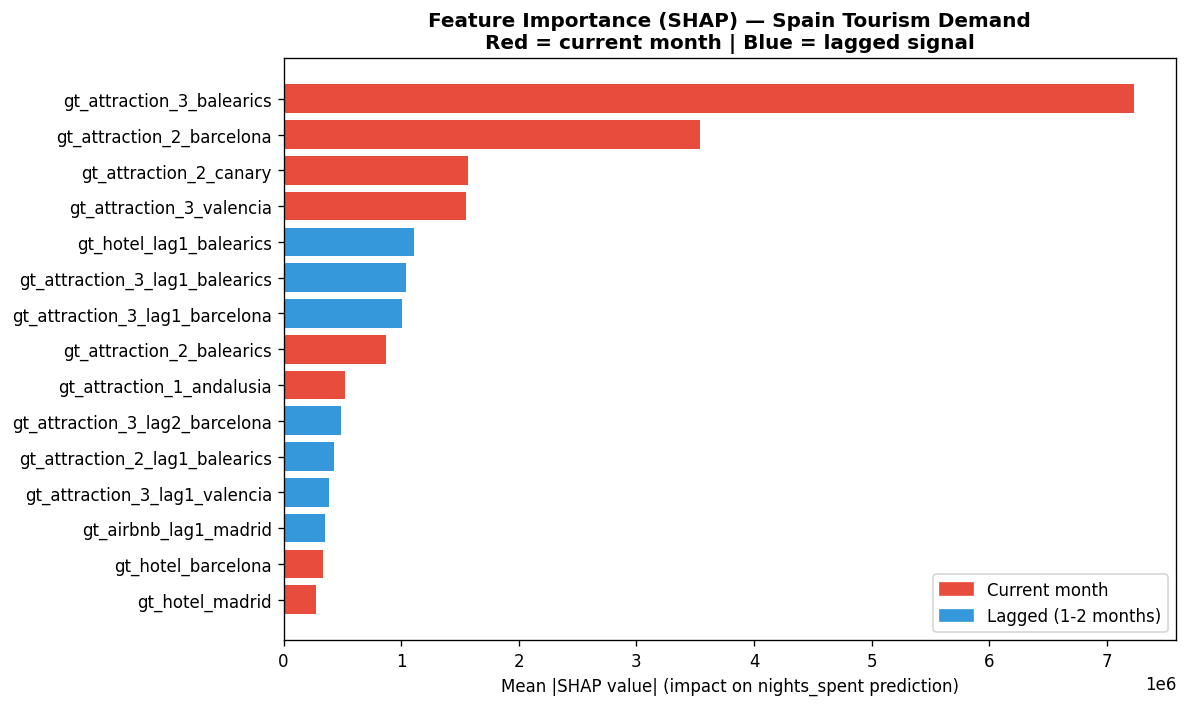

Saved shap_bar.png


In [12]:
# ── SHAP analysis ─────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

shap_mean = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns).sort_values(ascending=False)

print('Top 15 features by mean |SHAP|:')
print(shap_mean.head(15).round(2).to_string())

# ── SHAP bar chart ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
top15 = shap_mean.head(15)
colors = ['#e74c3c' if '_lag' not in f else '#3498db' for f in top15.index]
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
ax.set_xlabel('Mean |SHAP value| (impact on nights_spent prediction)')
ax.set_title('Feature Importance (SHAP) — Spain Tourism Demand\nRed = current month | Blue = lagged signal', fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#e74c3c', label='Current month'),
                   Patch(color='#3498db', label='Lagged (1-2 months)')], loc='lower right')
plt.tight_layout()
plt.savefig(BASE / 'data' / 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved shap_bar.png')

## Section 6: Visualizations

### 6a: Early Warning Chart
Shows Spain national bed nights vs. GT attention signal for each city over time.  
Red shading = arrival shock months. Orange dots = attention spikes.

**The "smoking gun":** Look for orange dots appearing 1-2 months before red-shaded arrival peaks.

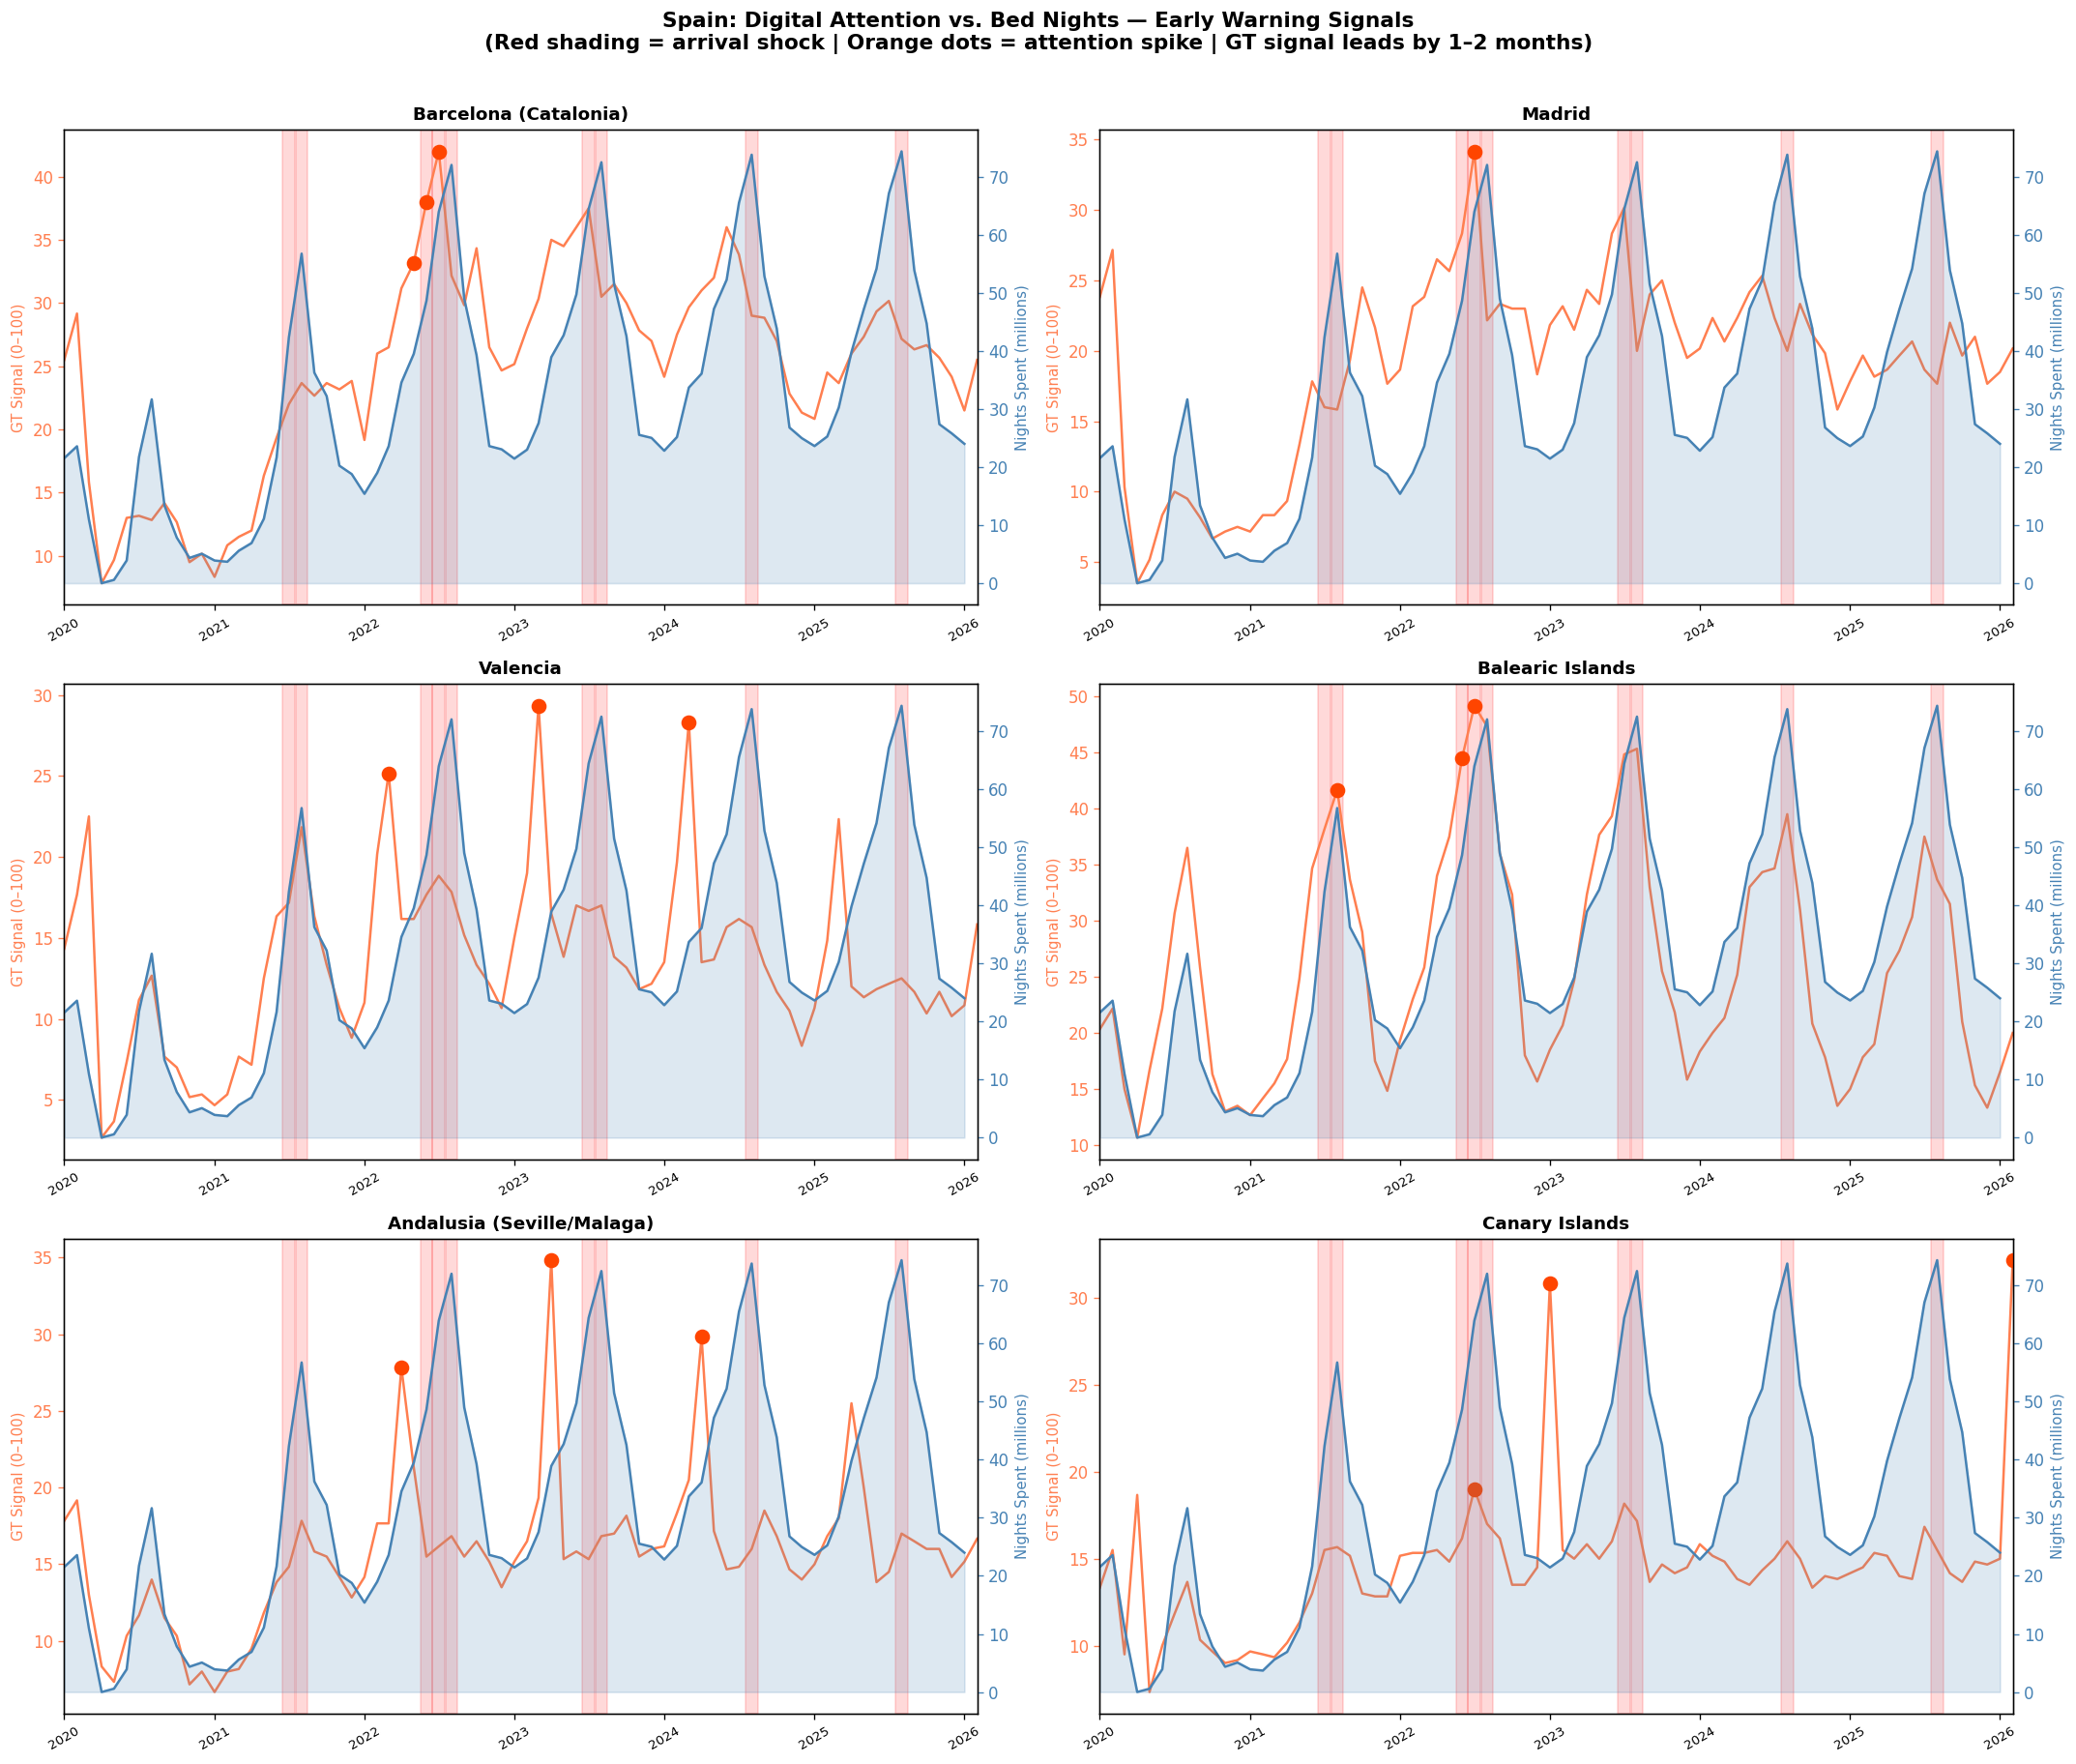

Saved early_warning_chart.png


In [13]:
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.flatten()

city_labels = {
    'barcelona': 'Barcelona (Catalonia)',
    'madrid':    'Madrid',
    'valencia':  'Valencia',
    'balearics': 'Balearic Islands',
    'andalusia': 'Andalusia (Seville/Malaga)',
    'canary':    'Canary Islands',
}

for i, city in enumerate(CITIES):
    ax  = axes[i]
    ax2 = ax.twinx()
    sub = shock_long[shock_long['city'] == city].sort_values('date')

    # Bed nights (right axis)
    ax2.fill_between(sub['date'], sub['nights_spent'] / 1e6, alpha=0.18, color='steelblue')
    ax2.plot(sub['date'], sub['nights_spent'] / 1e6, color='steelblue', linewidth=1.5, label='Nights (M)')
    ax2.set_ylabel('Nights Spent (millions)', color='steelblue', fontsize=9)
    ax2.tick_params(axis='y', colors='steelblue')

    # GT combined signal (left axis)
    ax.plot(sub['date'], sub['gt_combined'], color='coral', linewidth=1.5, label='GT Combined')
    ax.set_ylabel('GT Signal (0–100)', color='coral', fontsize=9)
    ax.tick_params(axis='y', colors='coral')

    # Shade arrival shock months
    for _, row in sub[sub['is_arrival_shock'] == 1].iterrows():
        ax.axvspan(row['date'] - pd.Timedelta(days=15),
                   row['date'] + pd.Timedelta(days=15),
                   alpha=0.15, color='red', zorder=0)

    # Mark attention spikes
    attn = sub[sub['is_attention_spike'] == 1]
    ax.scatter(attn['date'], attn['gt_combined'], color='orangered', s=70, zorder=5, label='Attention spike')

    ax.set_title(city_labels[city], fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.set_xlim(sub['date'].min(), sub['date'].max())

plt.suptitle(
    'Spain: Digital Attention vs. Bed Nights — Early Warning Signals\n'
    '(Red shading = arrival shock | Orange dots = attention spike | GT signal leads by 1–2 months)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(BASE / 'data' / 'early_warning_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved early_warning_chart.png')

### 6b: City Resilience Radar Chart

5 metrics per city, normalised 0–1:
- **Lead Rate**: fraction of arrival shocks preceded by attention spikes (higher = better early warning)
- **GT Volatility**: coefficient of variation of GT signal (higher = more viral behaviour)
- **Spike Intensity**: how many attention spikes relative to months observed
- **Demand Stability**: inverse of arrival shock rate (higher = more stable)
- **Signal Strength**: mean GT level (proxy for search volume interest)

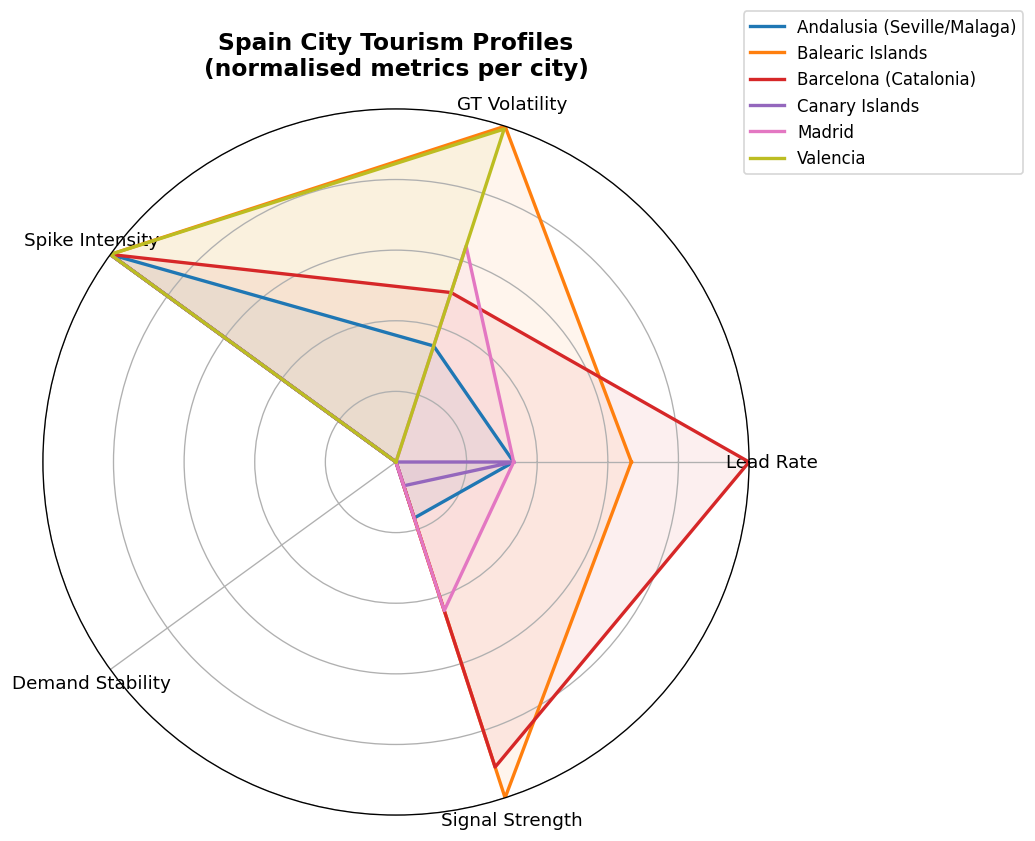

Saved resilience_radar.png

City metrics (raw):
                     label  lead_rate  gt_volatility  spike_intensity  demand_stability  signal_strength
Andalusia (Seville/Malaga)      0.111          0.300            0.041             0.878            0.156
          Balearic Islands      0.222          0.384            0.041             0.878            0.258
     Barcelona (Catalonia)      0.333          0.321            0.041             0.878            0.247
            Canary Islands      0.111          0.256            0.041             0.878            0.145
                    Madrid      0.111          0.338            0.014             0.878            0.190
                  Valencia      0.000          0.383            0.041             0.878            0.136


In [14]:
def compute_city_metrics(shock_long):
    records = []
    for city, grp in shock_long.groupby('city'):
        n        = len(grp)
        shocks   = grp['is_arrival_shock'].sum()
        spikes   = grp['is_attention_spike'].sum()
        led      = grp['attn_led_arrival'].sum()
        gt_mean  = grp['gt_combined'].mean()
        gt_std   = grp['gt_combined'].std()
        records.append({
            'city':             city,
            'label':            city_labels[city],
            'lead_rate':        led / shocks if shocks > 0 else 0,
            'gt_volatility':    gt_std / (gt_mean + 1e-9),
            'spike_intensity':  spikes / n,
            'demand_stability': 1 - (shocks / n),
            'signal_strength':  gt_mean / 100,
        })
    return pd.DataFrame(records)

radar_df = compute_city_metrics(shock_long)

# Normalize each metric 0–1
metric_cols = ['lead_rate','gt_volatility','spike_intensity','demand_stability','signal_strength']
for col in metric_cols:
    mn, mx = radar_df[col].min(), radar_df[col].max()
    radar_df[col + '_n'] = (radar_df[col] - mn) / (mx - mn + 1e-9)

norm_cols   = [c + '_n' for c in metric_cols]
categories  = ['Lead Rate', 'GT Volatility', 'Spike Intensity', 'Demand Stability', 'Signal Strength']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors  = plt.cm.tab10(np.linspace(0, 0.8, len(radar_df)))

for _, row in radar_df.iterrows():
    vals = [row[c] for c in norm_cols] + [row[norm_cols[0]]]
    color = colors[list(radar_df['city']).index(row['city'])]
    ax.plot(angles, vals, color=color, linewidth=2, label=row['label'])
    ax.fill(angles, vals, color=color, alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticklabels([])
ax.set_title('Spain City Tourism Profiles\n(normalised metrics per city)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=10)

plt.tight_layout()
plt.savefig(BASE / 'data' / 'resilience_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved resilience_radar.png')
print('\nCity metrics (raw):')
print(radar_df[['label'] + metric_cols].round(3).to_string(index=False))

## Section 7: Key Findings Summary

In [15]:
print('=' * 65)
print('SPAIN ANALYSIS — KEY FINDINGS')
print('=' * 65)

print(f'\nModel Performance (TimeSeriesSplit CV, 5 folds):')
print(f'  Mean MAPE: {scores_df.MAPE.mean():.1%} ± {scores_df.MAPE.std():.1%}')
print(f'  Mean R²:   {scores_df.R2.mean():.3f} ± {scores_df.R2.std():.3f}')

print(f'\nTop 5 Predictive Signals (SHAP):')
for feat, val in shap_mean.head(5).items():
    city_tag = next((c for c in CITIES if c in feat), '?')
    sig_tag  = next((s for s in GT_COLS if s in feat), feat)
    print(f'  {feat[:45]:45s}: {val:.2f}')

total_shocks = shock_long.groupby('city')['is_arrival_shock'].first().sum()
total_led    = shock_long.groupby('city')['attn_led_arrival'].sum().max()
print(f'\nArrival shocks detected: {total_shocks}')
print(f'Max attention-led shocks (best city): {total_led}')

print(f'\nAttention spikes per city:')
print(shock_long.groupby('city')['is_attention_spike'].sum().to_string())

print(f'\nOutput files:')
for f in ['shap_bar.png','early_warning_chart.png','resilience_radar.png','shock_table.csv']:
    path = BASE / 'data' / f
    status = '✓' if path.exists() else '✗'
    print(f'  {status} data/{f}')

SPAIN ANALYSIS — KEY FINDINGS

Model Performance (TimeSeriesSplit CV, 5 folds):
  Mean MAPE: 22.3% ± 9.3%
  Mean R²:   0.154 ± 0.665

Top 5 Predictive Signals (SHAP):
  gt_attraction_3_balearics                    : 7224443.01
  gt_attraction_2_barcelona                    : 3535996.70
  gt_attraction_2_canary                       : 1569833.42
  gt_attraction_3_valencia                     : 1547854.49
  gt_hotel_lag1_balearics                      : 1111991.88

Arrival shocks detected: 0
Max attention-led shocks (best city): 3

Attention spikes per city:
city
andalusia    3
balearics    3
barcelona    3
canary       3
madrid       1
valencia     3

Output files:
  ✓ data/shap_bar.png
  ✓ data/early_warning_chart.png
  ✓ data/resilience_radar.png
  ✗ data/shock_table.csv
